# Sentinel 5P ZARR Store

## Imports

In [ ]:
import zarr 
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.interpolate import griddata
from pyproj import Transformer, CRS
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

import reprojection
import os

### Path and Group for Zarr Store

In [76]:
product_type = "CO"
store_path = "/home/simon/eodc_datasync/private/eodc_logs/s5p/s5p.zarr"

store = zarr.storage.LocalStore(store_path)
group = zarr.group(store=store, path=product_type)

### Load with Xarray

In [77]:
import xarray as xr

ds = xr.open_zarr(store_path, group="CO", consolidated=True)
ds


<xarray.Dataset> Size: 465MB
Dimensions:                                (time: 2690, y: 60, x: 90,
                                            spatial_ref: 1)
Coordinates:
  * time                                   (time) datetime64[ns] 22kB 2018-04...
  * y                                      (y) float64 480B 1.8e+06 ... 1.21e+06
  * x                                      (x) float64 720B 4.5e+06 ... 5.39e+06
  * spatial_ref                            (spatial_ref) int8 1B 0
Data variables:
    carbonmonoxide_total_column            (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_corrected  (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_precision  (time, y, x) float64 116MB ...
    qa_value                               (time, y, x) float64 116MB ...
Attributes: (12/36)
    Conventions:                       CF-1.7
    title:                             TROPOMI/S5P CO Column
    freq:                              1D
    platform:                          S5P
    sensor:                            TROPOMI
    spatial_resolution:                10000
    ...                                ...
    product_version:                   1.5.0
    processing_status:                 Nominal
    Status_MET_2D:                     Nominal
    Status_CTM_CO:                     Nominal
    Status_CTMCH4:                     Nominal
    crs_wkt:                           PROJCS["WGS84/Equi7Europe",GEOGCS["WGS...

## Select Timeslice


In [78]:
ds_time_slice = ds.sel(time=slice("2024-01-01", "2024-12-31"))


In [79]:
qa = ds_time_slice.qa_value
carbon = ds_time_slice.carbonmonoxide_total_column

qa_valid = qa.where((~np.isnan(qa)) & (qa != -99))
ca_valid = carbon.where((~np.isnan(carbon)) & (carbon != -9999))
valid_count_per_time = qa_valid.count(dim=("y", "x"))
valid_count_per_month = valid_count_per_time.groupby("time.month").sum()



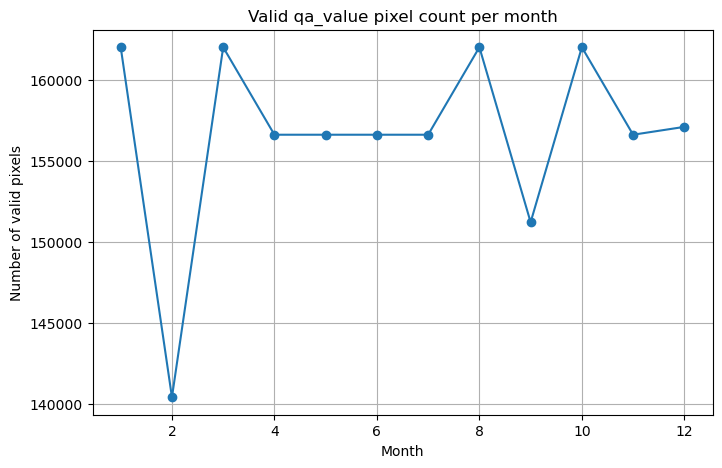

In [80]:
plt.figure(figsize=(8, 5))
valid_count_per_month.plot(marker="o")
plt.title("Valid qa_value pixel count per month")
plt.xlabel("Month")
plt.ylabel("Number of valid pixels")
plt.grid(True)
plt.show()


In [81]:
may = qa_valid.sel(time="2024-05")
june = qa_valid.sel(time="2024-06")
july = qa_valid.sel(time="2024-07")

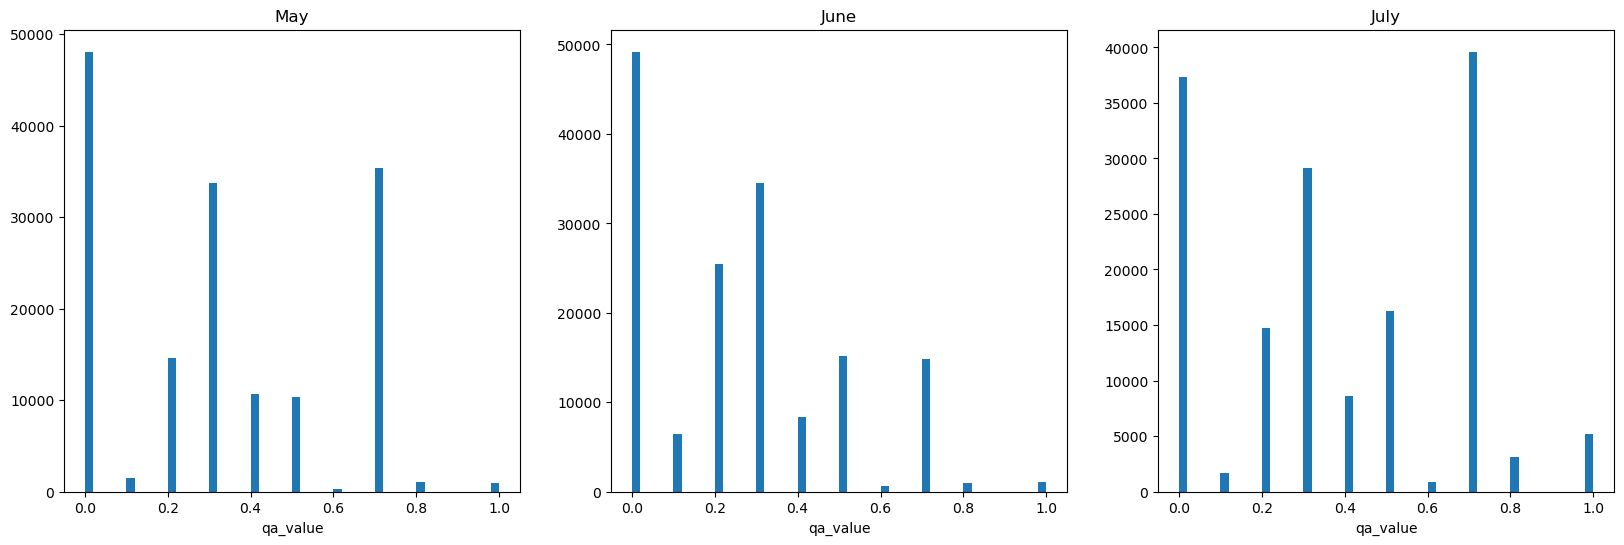

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

may.plot.hist(ax=axes[0], bins=50)
june.plot.hist(ax=axes[1], bins=50)
july.plot.hist(ax=axes[2], bins=50)


axes[0].set_title("May")
axes[1].set_title("June")
axes[2].set_title("July")

plt.show()

In [83]:
qa_threshold = 0.5

mask = (
    (ds_time_slice["qa_value"] >= qa_threshold)
)

ds_filtered = ds_time_slice.where(mask, drop=True)


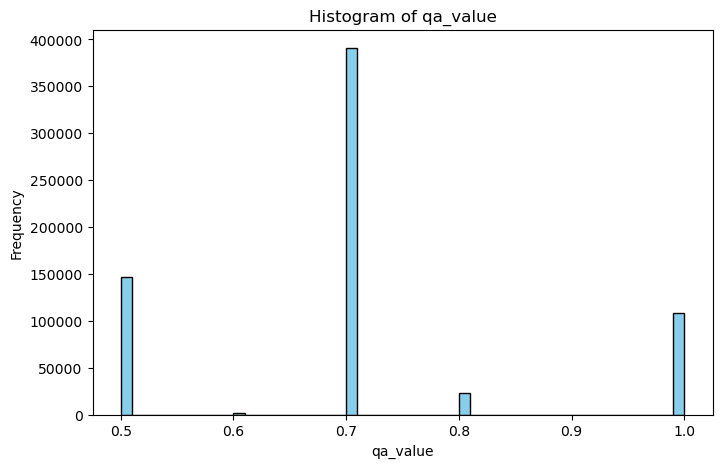

In [84]:
import matplotlib.pyplot as plt

data = ds_filtered.qa_value.values.flatten()

plt.figure(figsize=(8,5))
plt.hist(data, bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of qa_value")
plt.xlabel("qa_value")
plt.ylabel("Frequency")
plt.show()


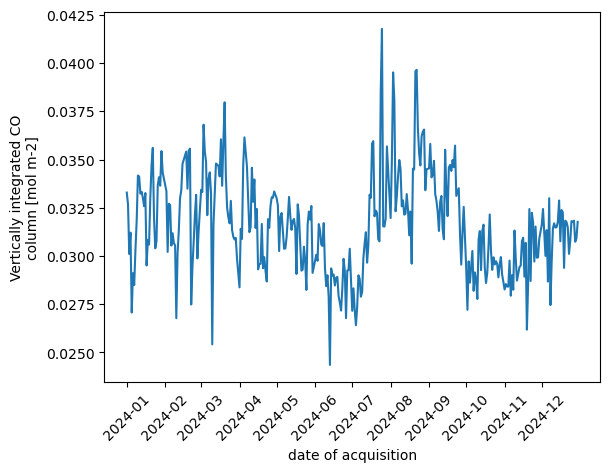

In [85]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots()
ds_filtered.carbonmonoxide_total_column.mean(dim=("y", "x")).plot(ax=ax)
time_values = ds_filtered.time.values
monthly_ticks = pd.date_range(start=str(time_values[0]), end=str(time_values[-1]), freq='MS')
ax.set_xticks(monthly_ticks)
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_ticks], rotation=45)

plt.show()


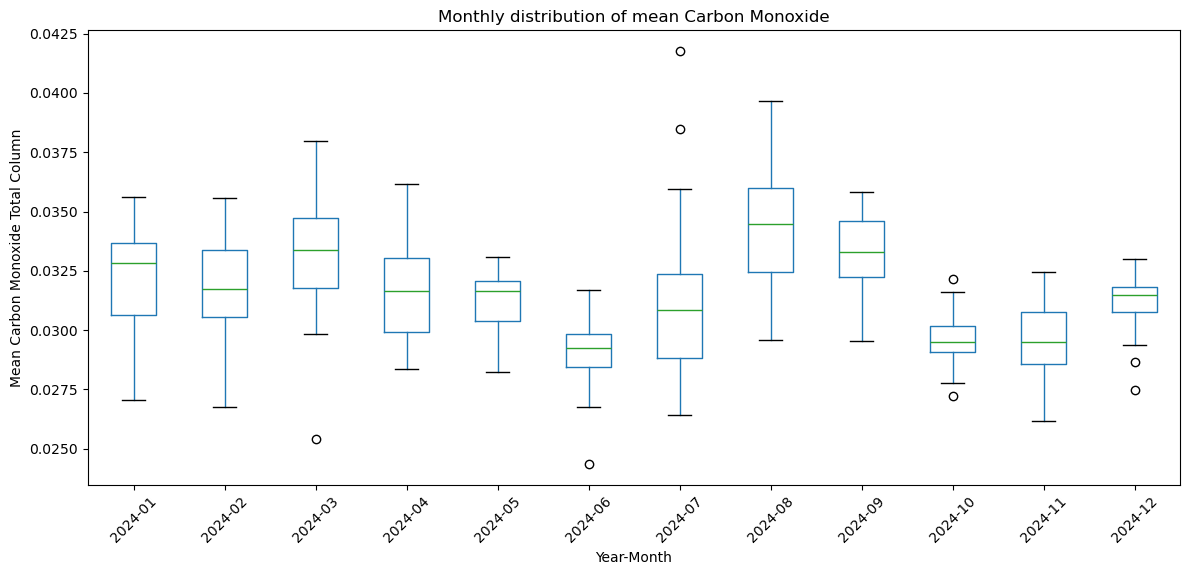

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

spatial_mean = ds_filtered.carbonmonoxide_total_column.mean(dim=("y", "x"))
co_series = spatial_mean.to_pandas()
co_df = co_series.reset_index()
co_df['year_month'] = co_df['time'].dt.to_period('M') 


fig, ax = plt.subplots(figsize=(12, 6))

co_df.boxplot(column='carbonmonoxide_total_column', by='year_month', ax=ax, grid=False)

ax.set_title('Monthly distribution of mean Carbon Monoxide')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Mean Carbon Monoxide Total Column')
plt.suptitle('')  
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


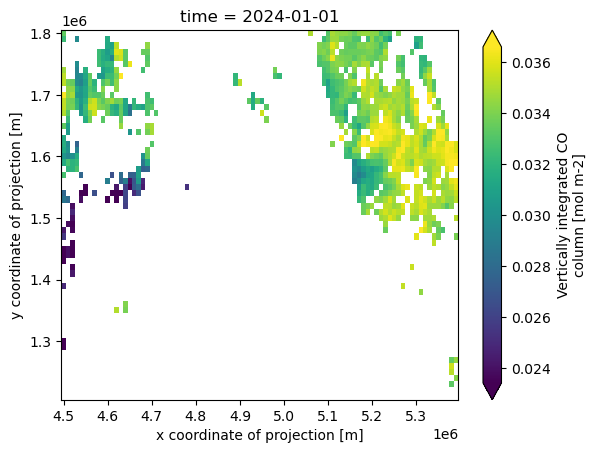

In [87]:
ds_filtered.carbonmonoxide_total_column.isel(time=0).plot(robust=True)

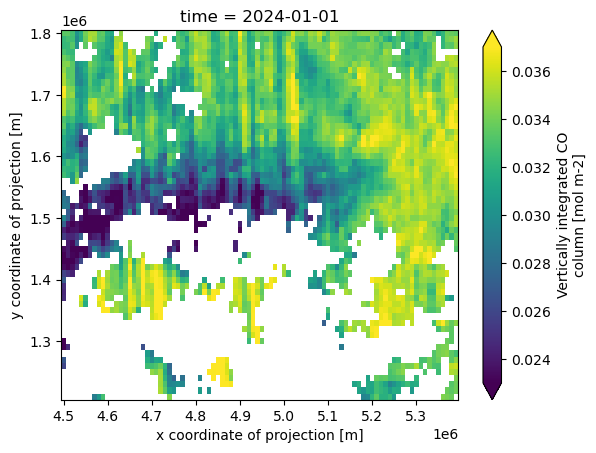

In [88]:
ds_time_slice.carbonmonoxide_total_column.isel(time=0).plot(robust=True)

## Visualize Carbon Monoxide Monthly Mean

In [89]:
transformer = Transformer.from_crs("EPSG:27704", "EPSG:4326", always_xy=True)
x,y = 5400000, 1800000
lon_max, lat_max = transformer.transform(x, y)
x,y = 4500000, 1200000
lon_min, lat_min = transformer.transform(x,y)

In [90]:
transformer = Transformer.from_crs("EPSG:27704", "EPSG:4326", always_xy=True)
x,y = 5400000, 1800000
lon_max, lat_max = transformer.transform(x, y)
x,y = 4500000, 1200000
lon_min, lat_min = transformer.transform(x,y)


X, Y = np.meshgrid(ds_time_slice["x"].values, ds_time_slice["y"].values)
lons_new, lats_new = transformer.transform(X,Y)

In [91]:
monthly_mean = (
    ds_time_slice.carbonmonoxide_total_column
    .groupby("time.month")
    .mean(dim="time")
)

month_names = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]


vmin = monthly_mean.min().item()
vmax = monthly_mean.max().item()

def plot_compare(month_left, month_right):
    fig, axs = plt.subplots(
        nrows=1, ncols=2, figsize=(16, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True
    )

    for ax, month in zip(axs, [month_left, month_right]):
        im = ax.pcolormesh(
            lons_new, lats_new,
            monthly_mean.isel(month=month).squeeze(),
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS)
        ax.set_xlim(lon_min - 1, lon_max + 1)
        ax.set_ylim(lat_min - 1, lat_max + 1)
        ax.set_title(month_names[month])

    fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.03, pad=0.02)
    plt.show()

left = widgets.Dropdown(
    options=[(name, i) for i, name in enumerate(month_names)],  # label: key swapped
    value=0,  # this must be present in keys (second element now)
    description="Left month:"
)

right = widgets.Dropdown(
    options=[(name, i) for i, name in enumerate(month_names)],
    value=1,
    description="Right month:"
)


widgets.interact(plot_compare, month_left=left, month_right=right);



interactive(children=(Dropdown(description='Left month:', options=(('January', 0), ('February', 1), ('March', …